# Predicting Student Academic Outcomes: A Classical ML vs Neural Network Study
**Author:** Divine Ebube Ifechukwude  
**Dataset:** Predict Students' Dropout and Academic Success — UCI #697  
**Date:** May 2026

In [1]:
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

zsh:1: command not found: pip


## Imports & Reproducibility

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

## Dataset Loading

This study uses the *Predict Students' Dropout and Academic Success* dataset (UCI Repository ID 697), curated by Martins et al. (2021) from a Portuguese higher-education institution. The dataset captures a wide range of student attributes, including demographic background, socioeconomic indicators, prior academic performance, and enrollment details; collected at the time of admission and updated at the end of the first and second academic semesters. The central problem it addresses is early identification of students at risk of dropping out, enabling institutions to intervene with targeted support before it is too late. Each student is labelled as one of three outcomes: *Dropout*, *Enrolled* (still studying at the time of data collection), or *Graduate*.

> Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). Early prediction of student's performance in higher education: A case study. In *Trends and Applications in Information Systems and Technologies* (pp. 166–175). Springer.

In [3]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = X.copy()
df['Target'] = y.values.ravel()

print('Dataset shape:', df.shape)
print()
print('Target value counts:')
print(df['Target'].value_counts())
print()
print('Dtypes summary:')
print(df.dtypes.value_counts())

Dataset shape: (4424, 37)

Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dtypes summary:
int64      29
float64     7
str         1
Name: count, dtype: int64


## Class Distribution

The dataset contains three outcome classes: Graduate (2,209 students, 49.9%),
Dropout (1,421 students, 32.1%), and Enrolled (794 students, 17.9%). This
distribution is imbalanced; Graduate accounts for nearly half of all instances,
while Enrolled represents less than one in five.

This imbalance has a direct consequence for model training. A classifier
optimising for accuracy can achieve approximately 49.9% accuracy by predicting
"Graduate" for every student, without learning anything meaningful about the
features. This is known as the majority class baseline, any model built in this
study must exceed it to be considered useful.

The mechanism behind this failure is gradient descent. During training, the model
iteratively adjusts its parameters to minimise loss. Because Graduate appears in
nearly half of all samples, consistently predicting it reduces the loss more
reliably than attempting to distinguish between all three classes. The model is
not making a deliberate choice; it is following the mathematical path of least
resistance that the loss landscape presents when classes are unequal.

For this reason, accuracy alone will not be used as the primary evaluation metric.
Instead, weighted F1-score; which balances precision and recall across all three
classes while accounting for their different sizes; will be the principal measure
of model performance. The Enrolled class, as the smallest group at 17.9%, is
expected to be the hardest to predict correctly and will be monitored closely
across all experiments. To address the imbalance during training, class weights
will be applied to penalise misclassification of minority-class students more
heavily than majority-class errors (King & Zeng, 2001).

> King, G., & Zeng, L. (2001). Logistic regression in rare events data.
> *Political Analysis, 9*(2), 137–163.

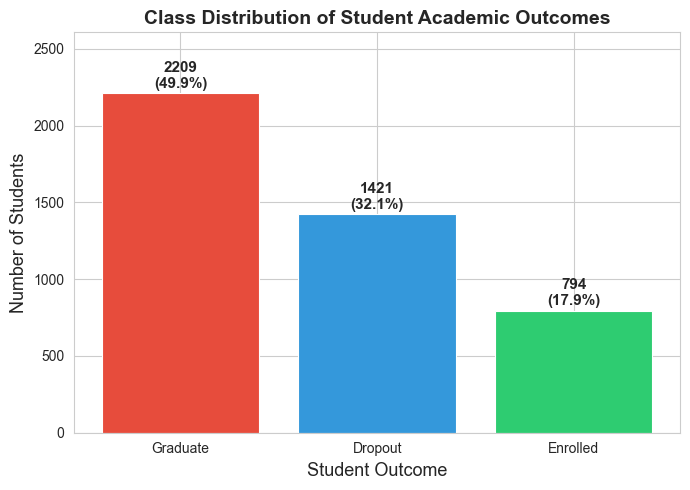

In [4]:
class_counts = df['Target'].value_counts()
class_pcts = df['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=0.8)

for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Student Outcome', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.set_title('Class Distribution of Student Academic Outcomes', fontsize=14, fontweight='bold')
ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout()
plt.show()

## Feature Statistics

Before any modelling decision is made, it is necessary to understand the 
numerical properties of each feature — specifically their scale, spread, and 
range. Descriptive statistics serve this purpose by revealing the mean, standard 
deviation, minimum, maximum, and quartile boundaries of every column in the 
dataset.

The statistic of immediate concern here is range — the difference between a 
feature's maximum and minimum value. Range directly determines how much a 
feature will influence distance-based models such as Support Vector Machines, 
and how aggressively it will drive weight updates in gradient-based models such 
as the neural network to be implemented in Part 3. A feature with a range of 
9,958 will dominate both distance calculations and gradient magnitudes over a 
feature with a range of 1, regardless of whether it is actually more informative 
— a distortion that has nothing to do with predictive value and everything to do 
with numerical scale (Bishop, 2006).

The results confirm this concern. The feature with the largest range is Course, 
spanning 9,958 units. However, Course is a categorical identifier encoded as an 
integer — its numerical magnitude carries no ordinal meaning, yet an unscaled 
model would treat a difference of 9,000 between two course codes as vastly more 
significant than a difference of 5 in units approved. The feature with the 
smallest range is Daytime/evening attendance, spanning exactly 1 unit as a 
binary indicator.

This finding makes feature standardisation not merely advisable but necessary. 
All 36 features will be transformed to zero mean and unit variance prior to 
training, using the z-score formula derived and applied manually in the 
preprocessing step. Critically, the parameters of this transformation — the mean 
μ and standard deviation σ for each feature — will be computed exclusively from 
the training split and applied to the test split without refitting, ensuring that 
no information from unseen data influences the scaling process. This discipline 
is essential to producing an honest estimate of generalisation performance 
(Hastie et al., 2009).

> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning.* Springer.  
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical 
> Learning* (2nd ed.). Springer.

In [5]:
desc = df.drop(columns='Target').describe().T
desc['range'] = desc['max'] - desc['min']

print('Descriptive statistics (transposed):')
display(desc)

largest_range_feat = desc['range'].idxmax()
smallest_range_feat = desc['range'].idxmin()

print(f"\nFeature with LARGEST range : '{largest_range_feat}' "
      f"(range = {desc.loc[largest_range_feat, 'range']:.2f})")
print(f"Feature with SMALLEST range: '{smallest_range_feat}' "
      f"(range = {desc.loc[smallest_range_feat, 'range']:.4f})")

Descriptive statistics (transposed):


,count,mean,std,min,25%,50%,75%,max,range
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000,5.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000,56.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000,9958.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000,42.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000,95.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000,108.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000,43.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000,43.000000



Feature with LARGEST range : 'Course' (range = 9958.00)
Feature with SMALLEST range: 'Daytime/evening attendance' (range = 1.0000)


## Correlation Heatmap

A correlation heatmap visualises the pairwise linear relationships among all features and the target variable simultaneously. High inter-feature correlations (multicollinearity) can destabilise linear models and inflate coefficient variance, making it harder to attribute predictive power to individual features. Strong correlations between individual features and the target, on the other hand, signal potentially high-signal predictors worth prioritising. Understanding this structure informs both feature selection strategies and the choice between linear and non-linear model families.

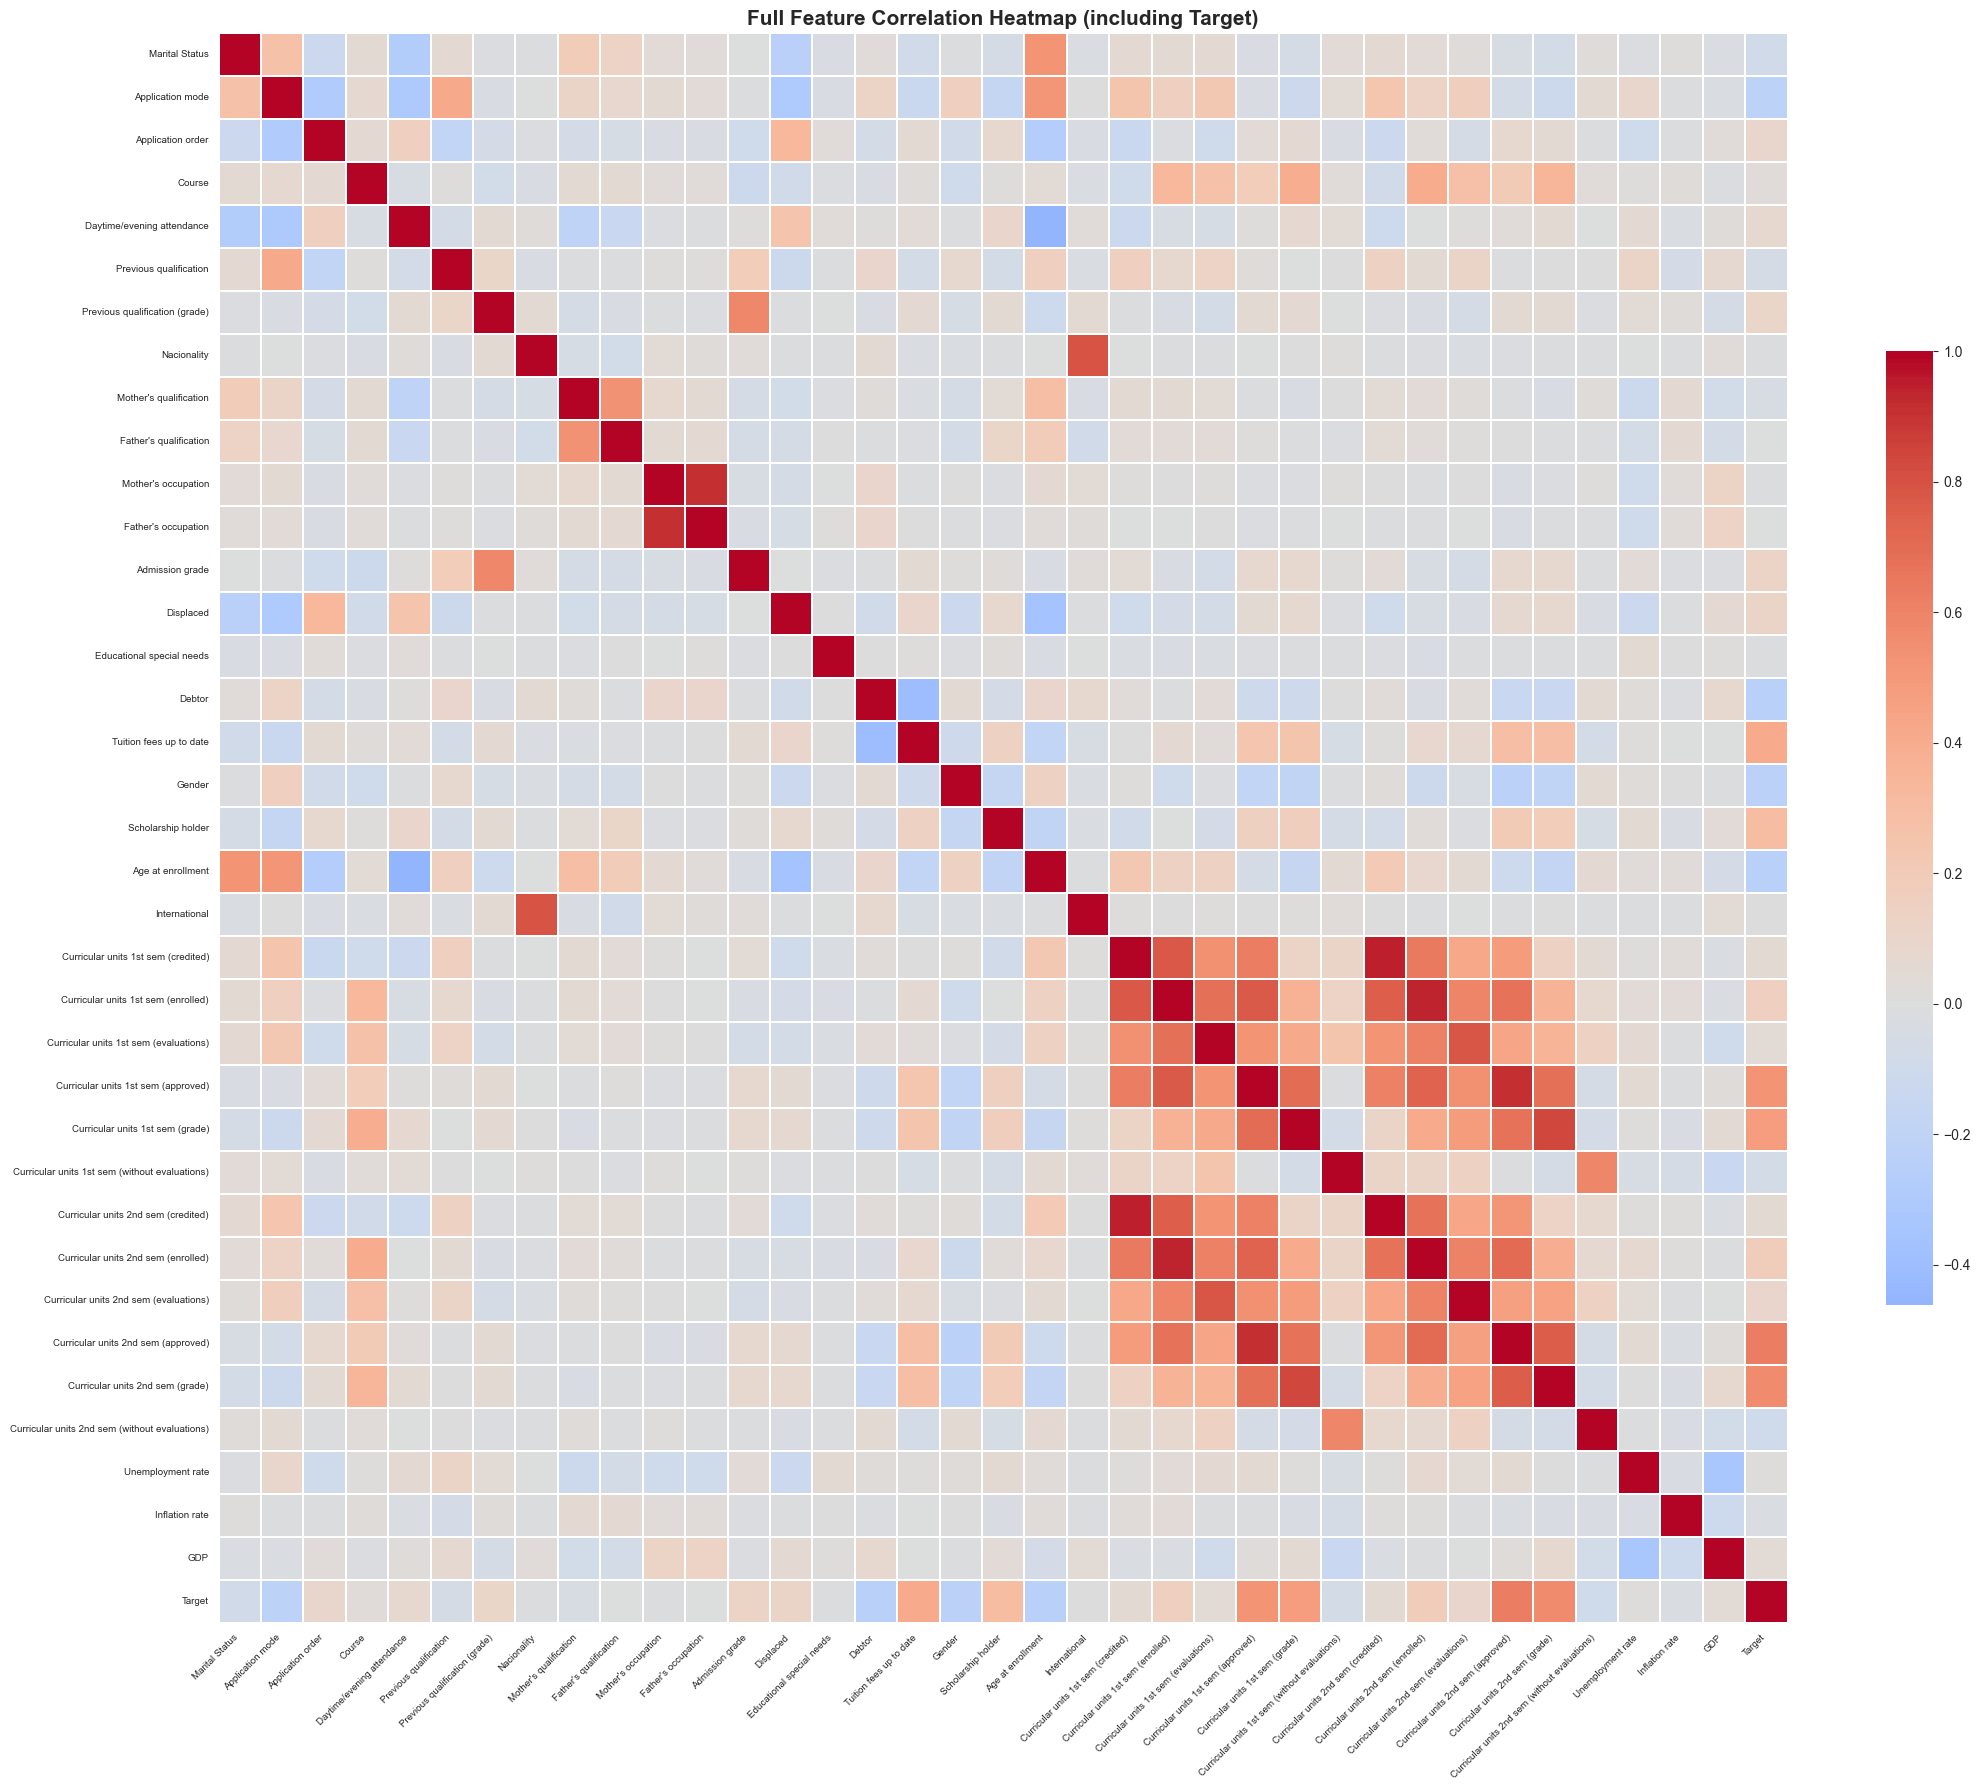

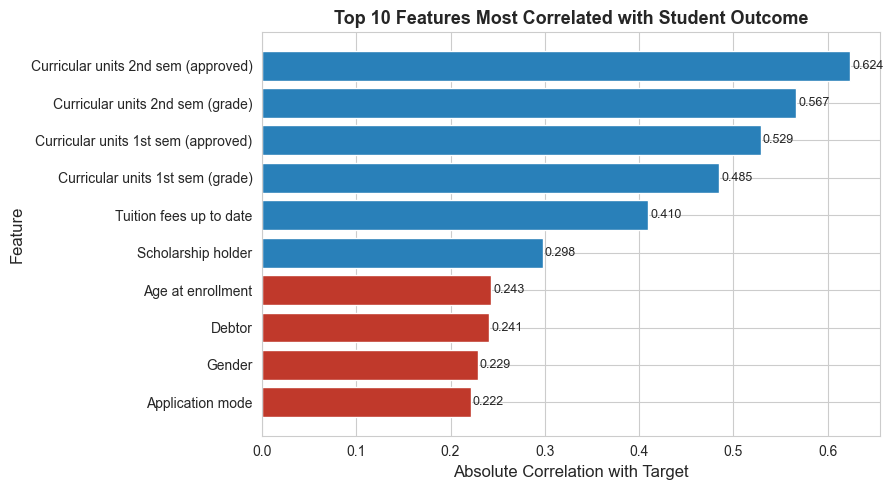

In [6]:
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr = df.copy()
df_corr['Target'] = df_corr['Target'].map(label_map)

corr_matrix = df_corr.corr()

# --- Full heatmap ---
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Full Feature Correlation Heatmap (including Target)', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# --- Top 10 features correlated with Target ---
target_corr = corr_matrix['Target'].drop('Target').abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2980b9' if corr_matrix['Target'].loc[f] >= 0 else '#c0392b' for f in target_corr.index]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Absolute Correlation with Target', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Features Most Correlated with Student Outcome', fontsize=13, fontweight='bold')
for i, (val, feat) in enumerate(zip(target_corr.values[::-1], target_corr.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# EDA Findings & Implications

> TODO: To be completed after reviewing the outputs above.